In [1]:
%run functions.ipynb
# import b2plot as b2 -Was pretty lame plugin
df_chg = pd.read_pickle('DlKKs_chgMC_df.p ')
df_mix = pd.read_pickle('DlKKs_mixMC_df.p')
df_cc = pd.read_pickle('DlKKs_ccMC_df.p')
df_uds = pd.read_pickle('DlKKs_udsMC_df.p')
df_off = pd.read_pickle('DlKKs_off_df.p')
df_dat = pd.read_pickle('DlKKs_data_df.p')
#df_cmc = pd.read_pickle('DlKKs_allsim_df.p')
df_cmc = pd.read_pickle('DlKKs_CMCX_df.p')

#---------------------------------- Data lumi = 365.290, BB cross-section = 1050000.0, Offpeak lumi = 42.740 #144643/577965 = 0.2502625591515057
df_cc2 = pd.read_pickle('old/DlKKs_ccMC_df.p')
df_chg2 = pd.read_pickle('old/DlKKs_chgMC_df.p')
df_mix2 = pd.read_pickle('old/DlKKs_mixMC_df.p')
df_dat2 = pd.read_pickle('old/DlKKs_data_df.p')
#--------------------------------- Generic MC lumi = 1461.16, wtMC = 0.250, wtMCOff = 0.029
datasmc = [df_chg,df_mix,df_cc,df_uds]
df_names = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)", r"off-resonance"]
df_namesmc = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)"]
datasmc_old = [df_chg2,df_mix2,df_cc2] #3.99 more data 
api = pdg.connect()
df_asim = df_cmc.copy() #(577965, 328) r x c initial
labbin = ['Signal','Background']
mc_weights1 = np.ndarray((577965,))
mc_weights1.fill(0.25)
mc_weights2 = np.ndarray((577965,))
mc_weights2.fill(0.002737551)
dat_weights1 = np.ndarray((144643,))
dat_weights1.fill(0.002737551)
sig_vars = ['nROE_Ch', 'nROE_ECL', 'nROE_KL', 'Q_ROE', 'M_ROE', 'Eextra_ROE', 'R2', 'cosTBTO',
     'nROE_ECL_loose', 'M_ROE_loose', 'Eextra_ROE_loose',
     'trkK0S_ECM', 'trkK0S_pCM', 'trkK0S_InvM', 'trkK0S_cosThCM', 'trkK0S_phiCM', 'trkK0S_charge',
     'trkK0S_isSignal', 'trkK0S_isSignalAcceptMissing',
     'trk_ECM', 'trk_pCM', 'trk_InvM', 'trk_cosThCM', 'trk_phiCM', 'trk_charge',
     'trk_isSignal', 'trk_isSignalAcceptMissing', 'trk_dr', 'trk_d0Err', 'trk_dz',
     'trk_nCDCHits', 'trk_nVXDHits', 'trk_ndf', 'trk_chi2', 'trk_lastCDCLayer',
     'K0S_ECM', 'K0S_pCM', 'K0S_InvM', 'K0S_cosThCM', 'K0S_phiCM', 'K0S_charge',
     'K0S_isSignal', 'K0S_isSignalAcceptMissing', 'K0S_chiProb', 'K0S_flightDistance',
     'K0S_flightDistanceErr', 'K0S_dr', 'K0S_dz',
     'nISR', 'cosK0Strk']

tag = ['BSL_ECM', 'BSL_pCM', 'BSL_InvM', 'BSL_cosThCM', 'BSL_phiCM', 'BSL_charge',
     'BSL_BchiProb', 'BSL_BflightDistance', 'BSL_BflightDistanceErr', 'BSL_Bdr', 'BSL_Bdz',
     'BSL_isSignal', 'BSL_isSignalAcceptMissing', 'BSL_cosBY',
     'eSL_ECM', 'eSL_pCM', 'eSL_InvM', 'eSL_cosThCM', 'eSL_phiCM', 'eSL_charge',
     'eSL_isSignal', 'eSL_isSignalAcceptMissing',
     'D0SL_ECM', 'D0SL_pCM', 'D0SL_InvM', 'D0SL_cosThCM', 'D0SL_phiCM', 'D0SL_charge',
     'D0SL_DchiProb', 'D0SL_DflightDistance', 'D0SL_DflightDistanceErr',
     'D0SL_Ddr', 'D0SL_Ddz', 'D0SL_isSignal', 'D0SL_isSignalAcceptMissing',
     'cosK0SeSL', 'cosK0SD0SL']
df_asim = set_modes_sig_Bchg(df_asim)
sig_1 = df_asim.query('(K0S_isSignal == 1) & (trk_isSignal == 1)').copy()
bkg_1 = df_asim.query('(K0S_isSignal != 1) | (trk_isSignal != 1)').copy()
sig_2 = df_asim.query('trkK0S_isSignalAcceptMissing == 1').copy()
bkg_2 = df_asim.query('trkK0S_isSignalAcceptMissing != 1').copy()
all_modes = get_mode_dicts() # Ordered as: B+, B-, B0, Bbar0, Bs0, Bsbar0, D*+, D*-, Ds+, Ds-, D+, D-, D0, Dbar0, Tau+, Tau-
signal0 = df_asim.query('(signal == 1110) | (signal == 1111) | (signal == 1112)') #no B+- -> mu/e +- nu
backgr0 = df_asim.query('(signal != 1110) & (signal != 1111) & (signal != 1112)')
            #note almost all trkK0S not from Gamma(4s) are 30353? or K∗(892)+- 

#plt.style.use("belle2")

#df_asim['signal'].isna()
#Global vars, imports, etc
#Nans only MC variables really, some minors otherwise like ID,chi2, etc
df_chg

,__experiment__,__run__,__event__,__production__,__candidate__,__ncandidates__,__eventType__,__weight__,Ecms,aBminusMode,aBplusMode,aB0Mode,aBbar0Mode,aD0Mode,aDbar0Mode,aDplusMode,aDminusMode,ECM,pCM,InvM,cosThCM,phiCM,PDG,charge,nROE_Ch,nROE_ECL,nROE_KL,Q_ROE,M_ROE,Eextra_ROE,R2,cosTBTO,nROE_ECL_loose,M_ROE_loose,Eextra_ROE_loose,mcECM,mcPCM,mcThetaCM,mcPhiCM,isSignal,mcErrors,mcPDG,genMotherID_0,genMotherPDG_0,genMotherPDG_1,genMotherPDG_2,isSignalAcceptMissing,BSL_ECM,BSL_pCM,BSL_InvM,BSL_cosThCM,BSL_phiCM,BSL_PDG,BSL_charge,BSL_BchiProb,BSL_BflightDistance,BSL_BflightDistanceErr,BSL_Bdr,BSL_Bdz,BSL_isSignal,BSL_mcErrors,BSL_mcPDG,BSL_genMotherID_0,BSL_genMotherPDG_0,BSL_genMotherPDG_1,BSL_isSignalAcceptMissing,BSL_decayModeID,BSL_cosBY,eSL_ECM,eSL_pCM,eSL_InvM,eSL_cosThCM,eSL_phiCM,eSL_PDG,eSL_charge,eSL_isSignal,eSL_mcErrors,eSL_mcPDG,eSL_genMotherID_0,eSL_genMotherPDG_0,eSL_genMotherPDG_1,eSL_isSignalAcceptMissing,eSL_electronID,eSL_muonID,D0SL_ECM,D0SL_pCM,D0SL_InvM,D0SL_cosThCM,D0SL_phiCM,D0SL_PDG,D0SL_charge,D0SL_DchiProb,D0SL_DflightDistance,D0SL_DflightDistanceErr,D0SL_Ddr,D0SL_Ddz,D0SL_mcECM,D0SL_mcPCM,D0SL_mcThetaCM,D0SL_mcPhiCM,D0SL_isSignal,D0SL_mcErrors,D0SL_mcPDG,D0SL_genMotherID_0,D0SL_genMotherPDG_0,D0SL_genMotherPDG_1,D0SL_isSignalAcceptMissing,D0SL_decayModeID,trkK0S_ECM,trkK0S_pCM,trkK0S_InvM,trkK0S_cosThCM,trkK0S_phiCM,trkK0S_PDG,trkK0S_charge,trkK0S_isSignal,trkK0S_mcErrors,trkK0S_mcPDG,trkK0S_genMotherID_0,trkK0S_genMotherPDG_0,trkK0S_genMotherPDG_1,trkK0S_isSignalAcceptMissing,trk_ECM,trk_pCM,trk_InvM,trk_cosThCM,trk_phiCM,trk_PDG,trk_charge,trk_isSignal,trk_mcErrors,trk_mcPDG,trk_genMotherID_0,trk_genMotherPDG_0,trk_genMotherPDG_1,trk_genMotherPDG_2,trk_isSignalAcceptMissing,trk_KID,trk_piID,trk_electronID_noSVD_noTOP,trk_muonID_noSVD,trk_dr,trk_d0Err,trk_dz,trk_nCDCHits,trk_nVXDHits,trk_ndf,trk_chi2,trk_lastCDCLayer,K0S_ECM,K0S_pCM,K0S_InvM,K0S_cosThCM,K0S_phiCM,K0S_PDG,K0S_charge,K0S_isSignal,K0S_mcErrors,K0S_mcPDG,K0S_genMotherID_0,K0S_genMotherPDG_0,K0S_genMotherPDG_1,K0S_genMotherPDG_2,K0S_isSignalAcceptMissing,K0S_chiProb,K0S_flightDistance,K0S_flightDistanceErr,K0S_dr,K0S_dz,pi1_ECM,pi1_pCM,pi1_InvM,pi1_cosThCM,pi1_phiCM,pi1_PDG,pi1_charge,pi1_isSignal,pi1_mcErrors,pi1_mcPDG,pi1_genMotherID_0,pi1_genMotherPDG_0,pi1_genMotherPDG_1,pi1_genMotherPDG_2,pi1_isSignalAcceptMissing,pi1_KID,pi1_piID,pi1_electronID_noSVD_noTOP,pi1_muonID_noSVD,pi1_dr,pi1_d0Err,pi1_dz,pi1_nCDCHits,pi1_nVXDHits,pi1_ndf,pi1_chi2,pi1_lastCDCLayer,pi2_ECM,pi2_pCM,pi2_InvM,pi2_cosThCM,pi2_phiCM,pi2_PDG,pi2_charge,pi2_isSignal,pi2_mcErrors,pi2_mcPDG,pi2_genMotherID_0,pi2_genMotherPDG_0,pi2_genMotherPDG_1,pi2_genMotherPDG_2,pi2_isSignalAcceptMissing,pi2_KID,pi2_piID,pi2_electronID_noSVD_noTOP,pi2_muonID_noSVD,pi2_dr,pi2_d0Err,pi2_dz,pi2_nCDCHits,pi2_nVXDHits,pi2_ndf,pi2_chi2,pi2_lastCDCLayer,nMCGen,MCGenPDG_0,MCGenMothIndex_0,MCGenPDG_1,MCGenMothIndex_1,MCGenPDG_2,MCGenMothIndex_2,MCGenPDG_3,MCGenMothIndex_3,MCGenPDG_4,MCGenMothIndex_4,MCGenPDG_5,MCGenMothIndex_5,MCGenPDG_6,MCGenMothIndex_6,MCGenPDG_7,MCGenMothIndex_7,MCGenPDG_8,MCGenMothIndex_8,MCGenPDG_9,MCGenMothIndex_9,MCGenPDG_10,MCGenMothIndex_10,MCGenPDG_11,MCGenMothIndex_11,MCGenPDG_12,MCGenMothIndex_12,MCGenPDG_13,MCGenMothIndex_13,MCGenPDG_14,MCGenMothIndex_14,MCGenPDG_15,MCGenMothIndex_15,MCGenPDG_16,MCGenMothIndex_16,MCGenPDG_17,MCGenMothIndex_17,MCGenPDG_18,MCGenMothIndex_18,MCGenPDG_19,MCGenMothIndex_19,MCGenPDG_20,MCGenMothIndex_20,MCGenPDG_21,MCGenMothIndex_21,MCGenPDG_22,MCGenMothIndex_22,MCGenPDG_23,MCGenMothIndex_23,MCGenPDG_24,MCGenMothIndex_24,MCGenPDG_25,MCGenMothIndex_25,MCGenPDG_26,MCGenMothIndex_26,MCGenPDG_27,MCGenMothIndex_27,MCGenPDG_28,MCGenMothIndex_28,MCGenPDG_29,MCGenMothIndex_29,MCGenPDG_30,MCGenMothIndex_30,MCGenPDG_31,MCGenMothIndex_31,MCGenPDG_32,MCGenMothIndex_32,MCGenPDG_33,MCGenMothIndex_33,MCGenPDG_34,MCGenMothIndex_34,MCGenPDG_35,MCGenMothIndex_35,MCGenPDG_36,MCGenMothIndex_36,MCGenPDG_37,MCGenMothIndex_37,MCGenPDG_38,MCGenMothIndex_38,

In [15]:
ovws_sig1 = get_modes_sig_Bchg(sig_1)
ovws_sig2 = get_modes_sig_Bchg(sig_2)
ovws_bkg1 = get_modes_sig_Bchg(bkg_1)
ovws_bkg2 = get_modes_sig_Bchg(bkg_2)
#display(Math(all_modes[0][1117]))
#df_asim['trk_PDG'].value_counts()
#
a,b,c,d,e = ovws_sig1
f,g,h,ii, j = ovws_bkg1
p,o,k,l,m = get_modes_sig_Bchg(df_asim)

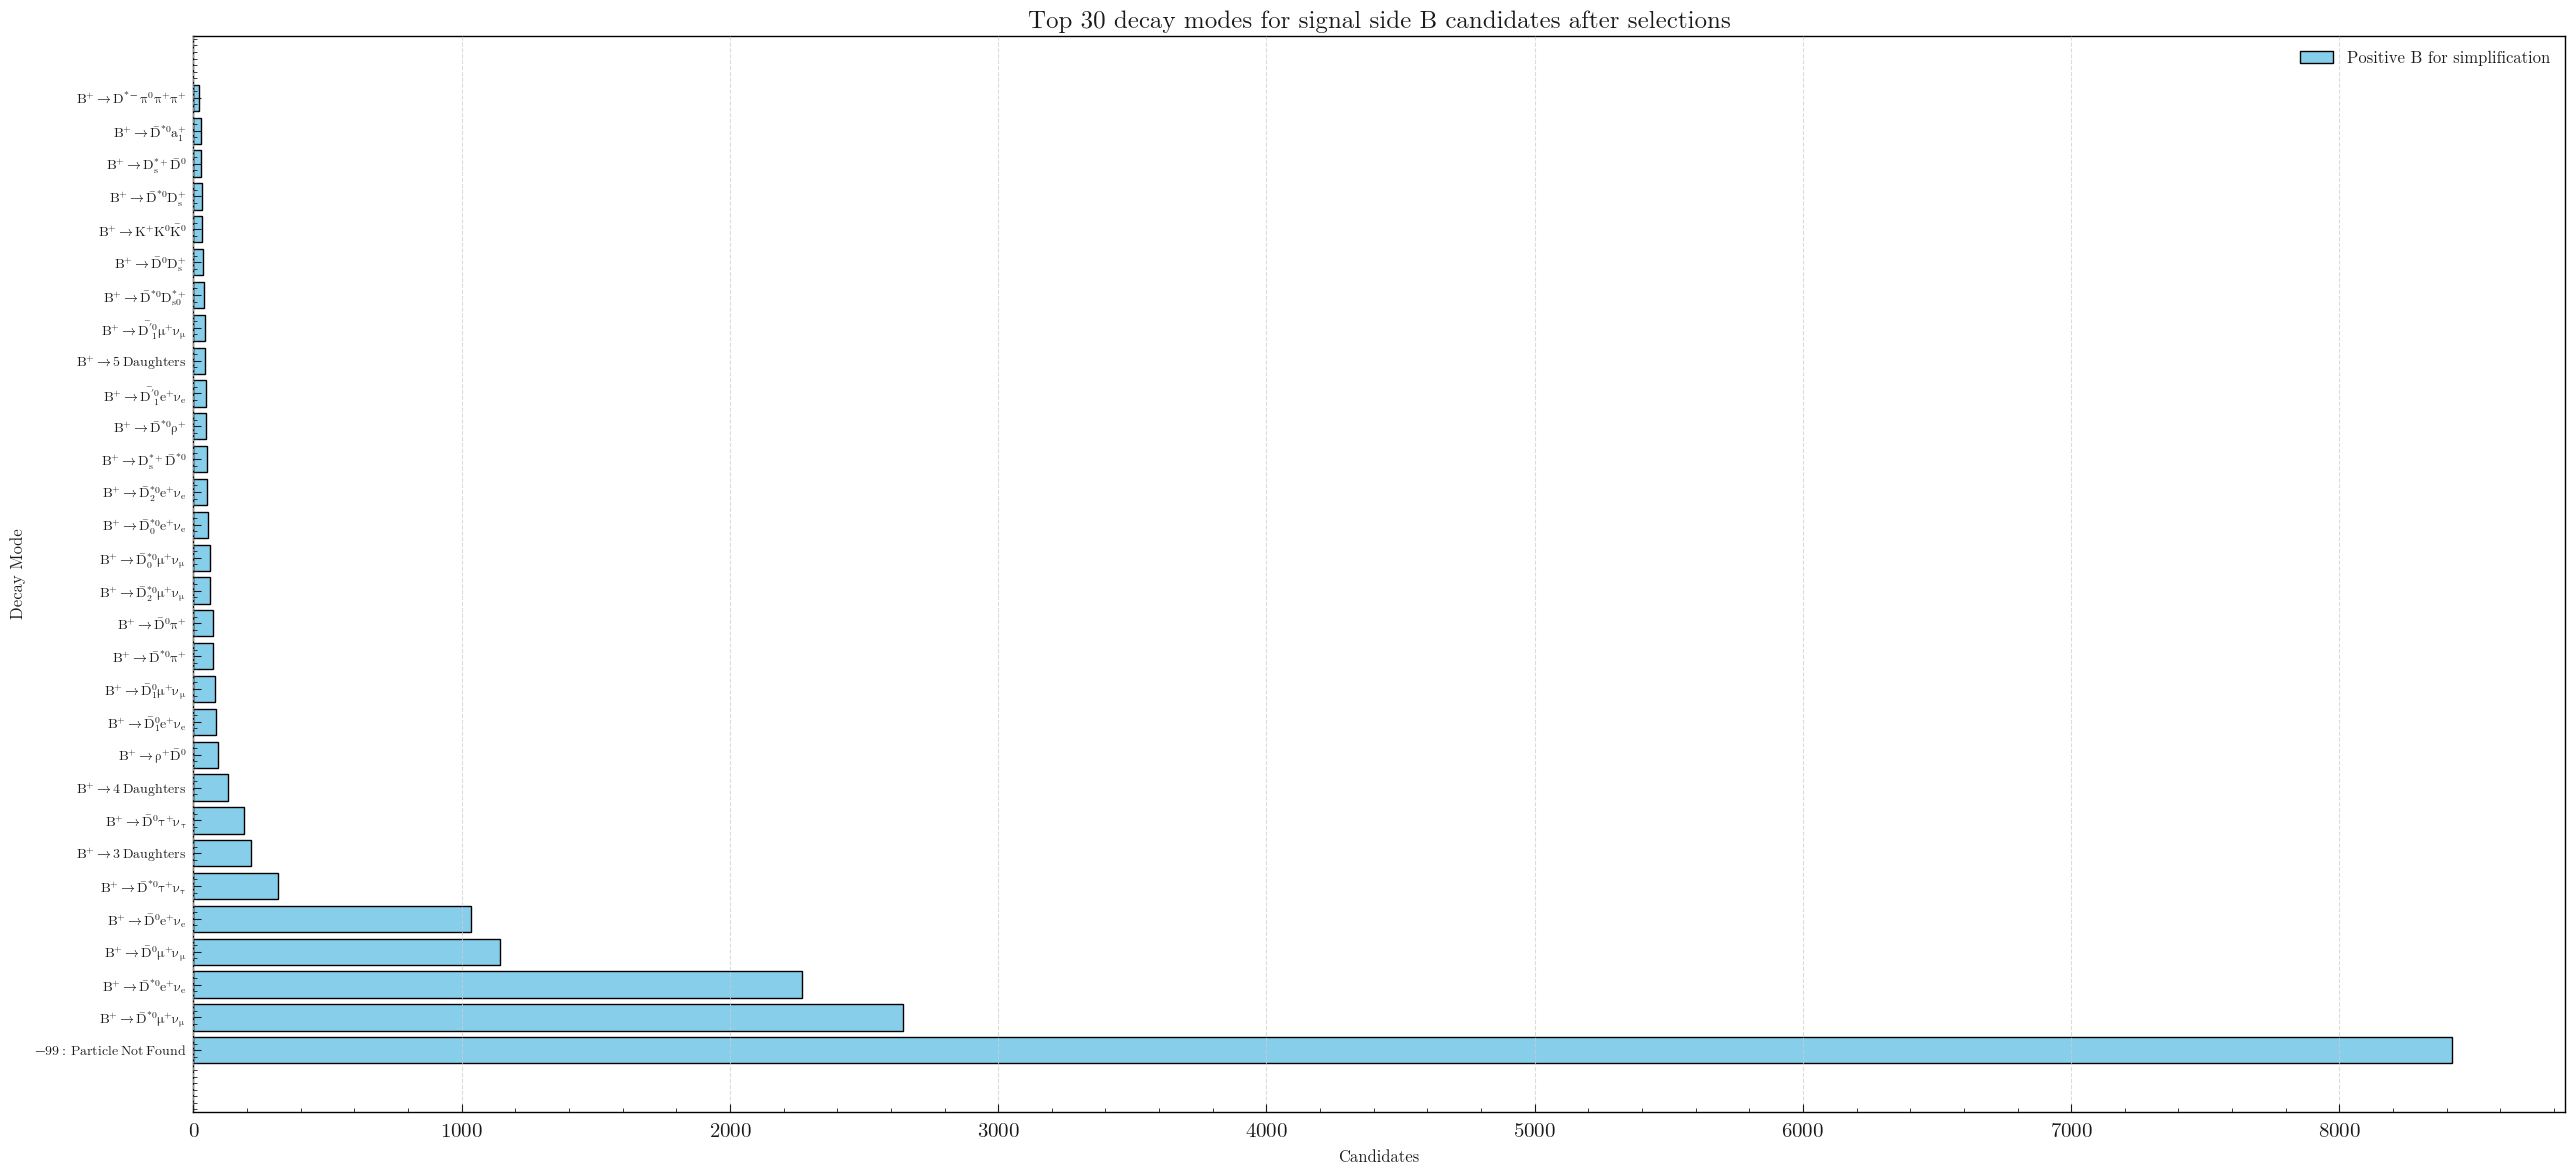

In [16]:
a,b,c,d,e = ovws_sig1
f,g,h,ii, j = ovws_bkg1
p,o,k,l,m = get_modes_sig_Bchg(df_asim)
(df_asim['trk_charge'] == df_asim['eSL_charge']).sum()


mu_sim = sel_mu(df_asim)
epos_sims = sel_epos(df_asim)
k_sims = sel_kchg(df_asim)
pi_sims = sel_pichg(df_asim)
sel_trks = [sel_mu, sel_epos, sel_pichg, sel_kchg]
trknames = [r'$\mu^+/\mu^-$ channel',r'$e^+/e^-$ channel',r'$K^+/K^-$ channel',r'$\pi^+/\pi^-$ track']
def sel_ini(df):
    df_t = df.copy()
    df_t = df_t.query('(K0S_InvM > 0.489) & (K0S_InvM < 0.5056) & (BSL_BchiProb > 1e-8) & (nROE_Ch == 0) & (Eextra_ROE < 0.93) & (Eextra_ROE_loose < 1.84)')
    df_t = df_t.query('(BSL_cosBY > -3) & (BSL_cosBY < 1.1) & (M_ROE_loose < 6.58) & (M_ROE < 4) & (K0S_flightDistance > 0.14) & (K0S_flightDistanceErr < 0.5) & (R2 < 0.73)')
    df_t = df_t.query('(trk_dz > -1.8) & (trk_dz < 1.8) & (K0S_dz > -6.8) & (K0S_dz < 3.4) & (K0S_dr < 9.3) & (trkK0S_ECM < 20)')
    df_t = df_t.query('(K0S_pCM < 2.5) & (trk_pCM < 2.5) & (eSL_pCM < 2.5) & (nROE_KL) < 12')
    return df_t
sel_ini0 = sel_ini(df_asim)
modes = 30
top_twent = sel_ini0['signal'].value_counts().head(modes)




cols = top_twent.index
vals = top_twent.values
col2 = [f"${all_modes['Bplus'][abs(col)]}$" for col in cols]

fig4 = plt.figure(figsize=(26, 12))
plt.barh(range(len(vals)), vals, color='skyblue', edgecolor='black', label='Positive B for simplification')
plt.xlabel("Candidates", fontsize=12)
plt.ylabel("Decay Mode", fontsize=12)
plt.title(f'Top {modes} decay modes for signal side B candidates after selections')
plt.yticks(range(len(col2)), col2, fontsize=10)
plt.tight_layout()
fig4.savefig("show4.svg", format='svg', bbox_inches='tight')

plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



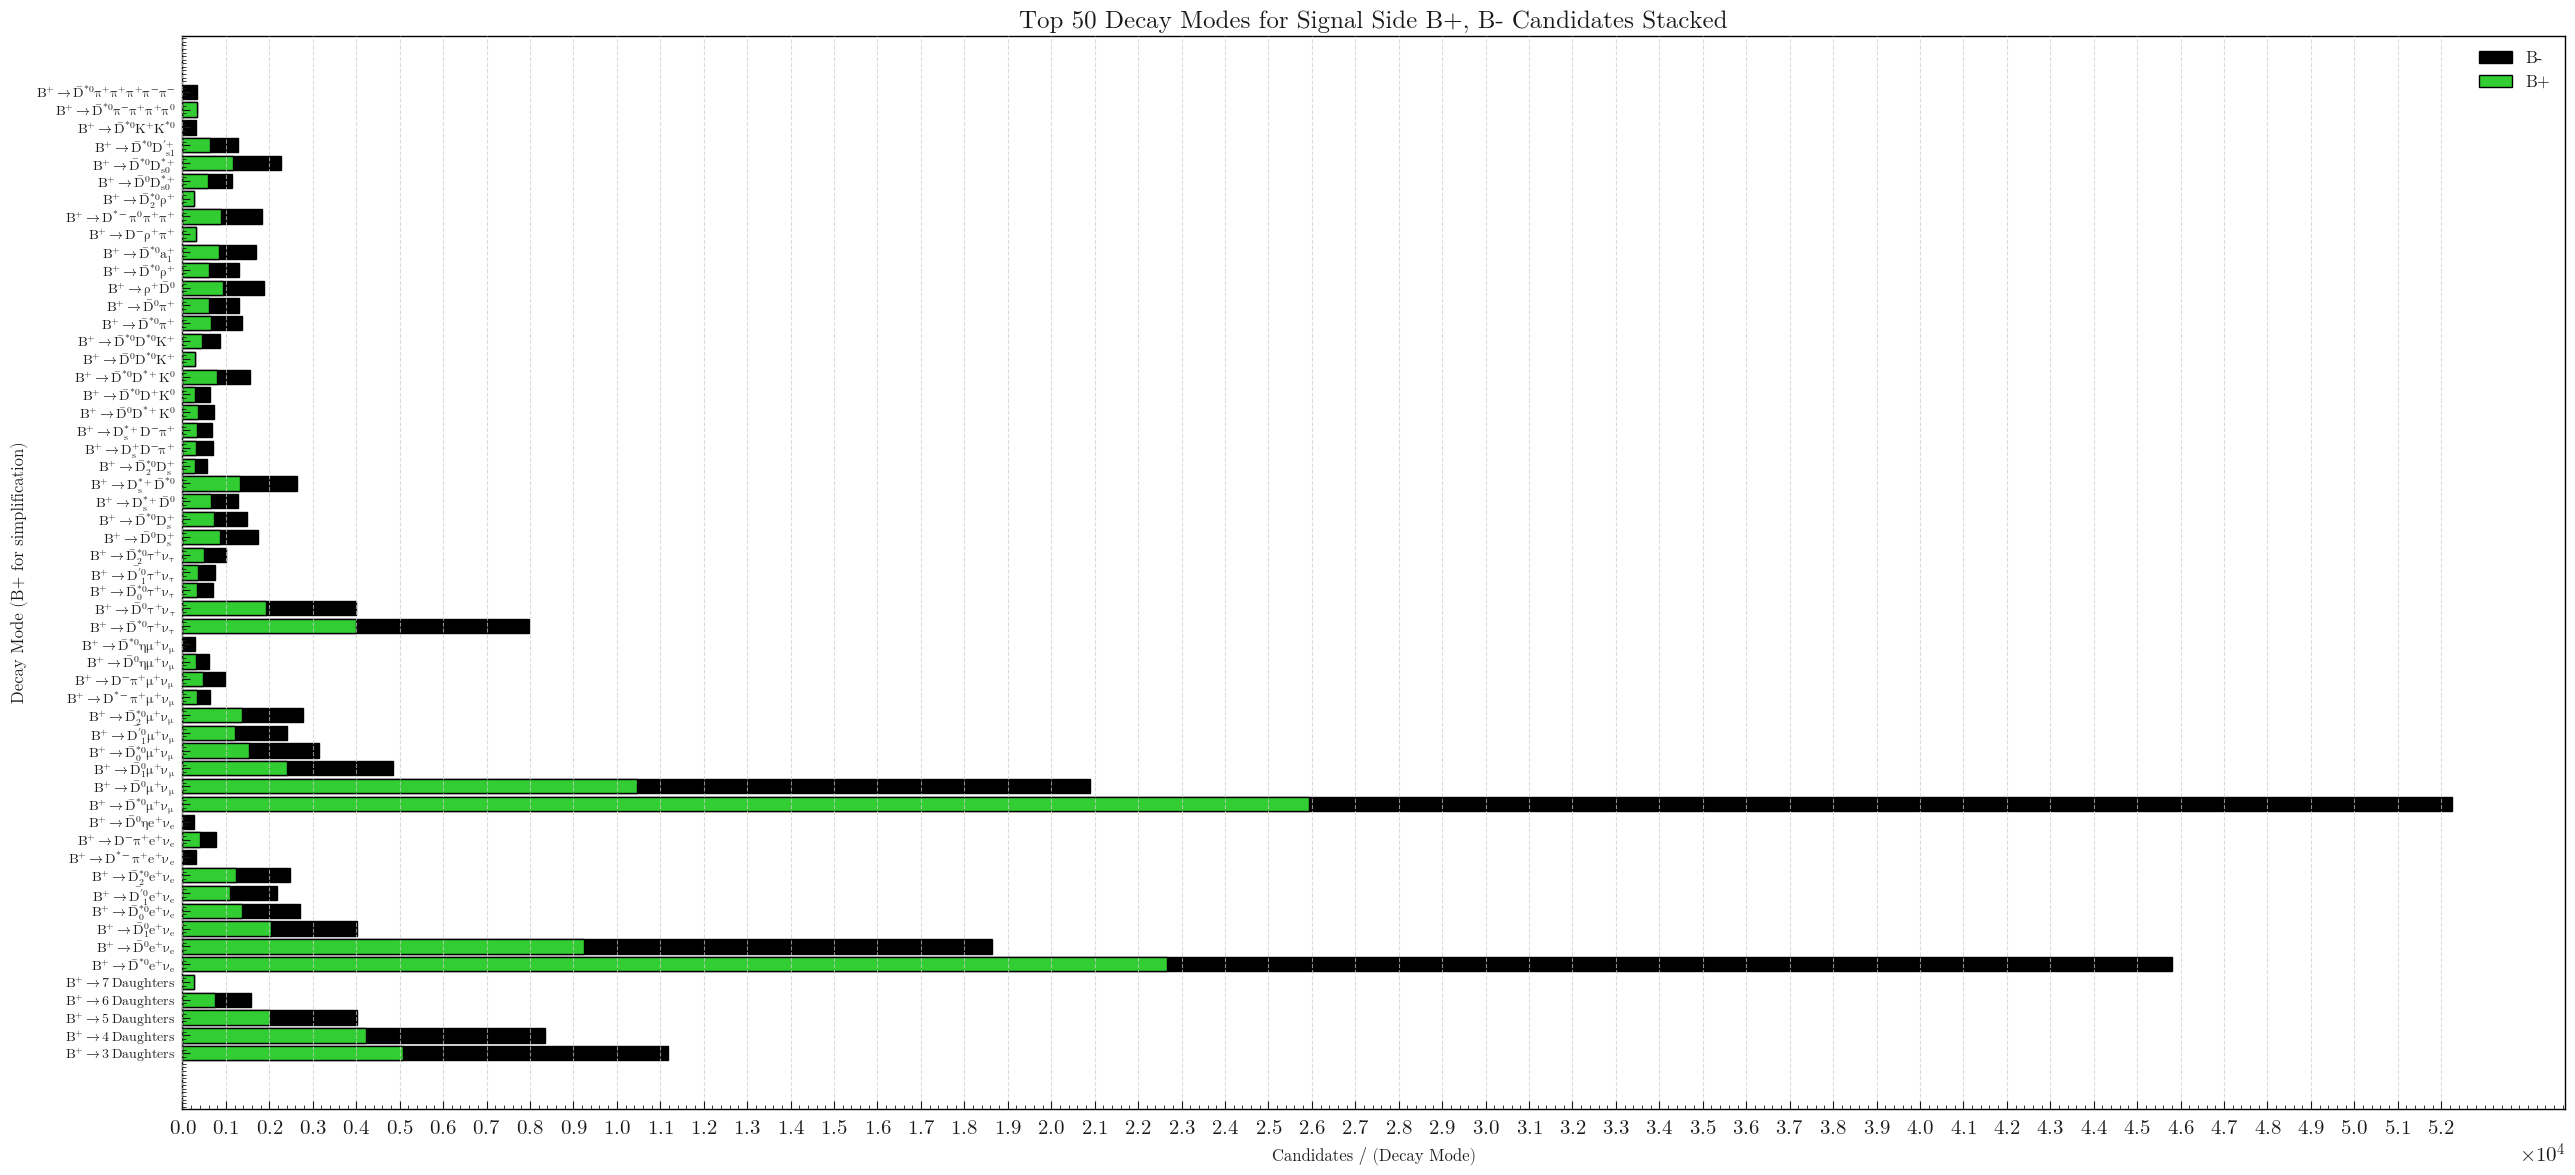

In [17]:
bp, bm = grab_signals_Bchg(df_asim)
count = 50
top_bp = bp[bp != 99.0].value_counts().head(count)
top_bm = bm[bm != 99.0].value_counts().head(count)
x = set(top_bp.index)
y = set(top_bm.index)
xy = list(x-y)
yx = list(y-x)
combined = top_bp.add(top_bm, fill_value=0).astype(int)
combined = combined.sort_index()
cols = combined.index
vals = combined.values

for val0 in yx:
    top_bp[val0] = 0
for val0 in xy:
    top_bm[val0] = 0

top_bp = top_bp.sort_index()
top_bm = top_bm.sort_index()

labs = [f"${all_modes['Bplus'][col]}$" for col in cols]  #all pos ffor bm and bp by design, no abs needed
fig5 = plt.figure(figsize=(26, 12))
#plt.barh(range(len(vals)), vals, color='white', edgecolor='black', label='Total B+,B-')
plt.barh(range(len(vals)),top_bm.values+top_bp.values,color='black',alpha=1,edgecolor='black',label='B-',zorder=0)
plt.barh(range(len(vals)),top_bp.values,color='limegreen',alpha=1,edgecolor='black',label='B+')
plt.xlabel("Candidates / (Decay Mode)", fontsize=12)
plt.ylabel("Decay Mode (B+ for simplification)", fontsize=12)
plt.title(f'Top {count} Decay Modes for Signal Side B+, B- Candidates Stacked')
plt.yticks(range(len(cols)), labs, fontsize=10)
plt.xticks(np.arange(0,max(vals),1000))
plt.tight_layout()
#plt.barh(range(len(vals)),np.zeros(len(vals)),color='darkgreen', alpha=1,edgecolor='black',label='B+,B- overlap')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
#fig5.savefig("show6_stk.svg", format='svg', bbox_inches='tight')

#Worked for 40, unsure 50
#conclusion, overall B+ has more decays than B- in the top 40 and 50 modes

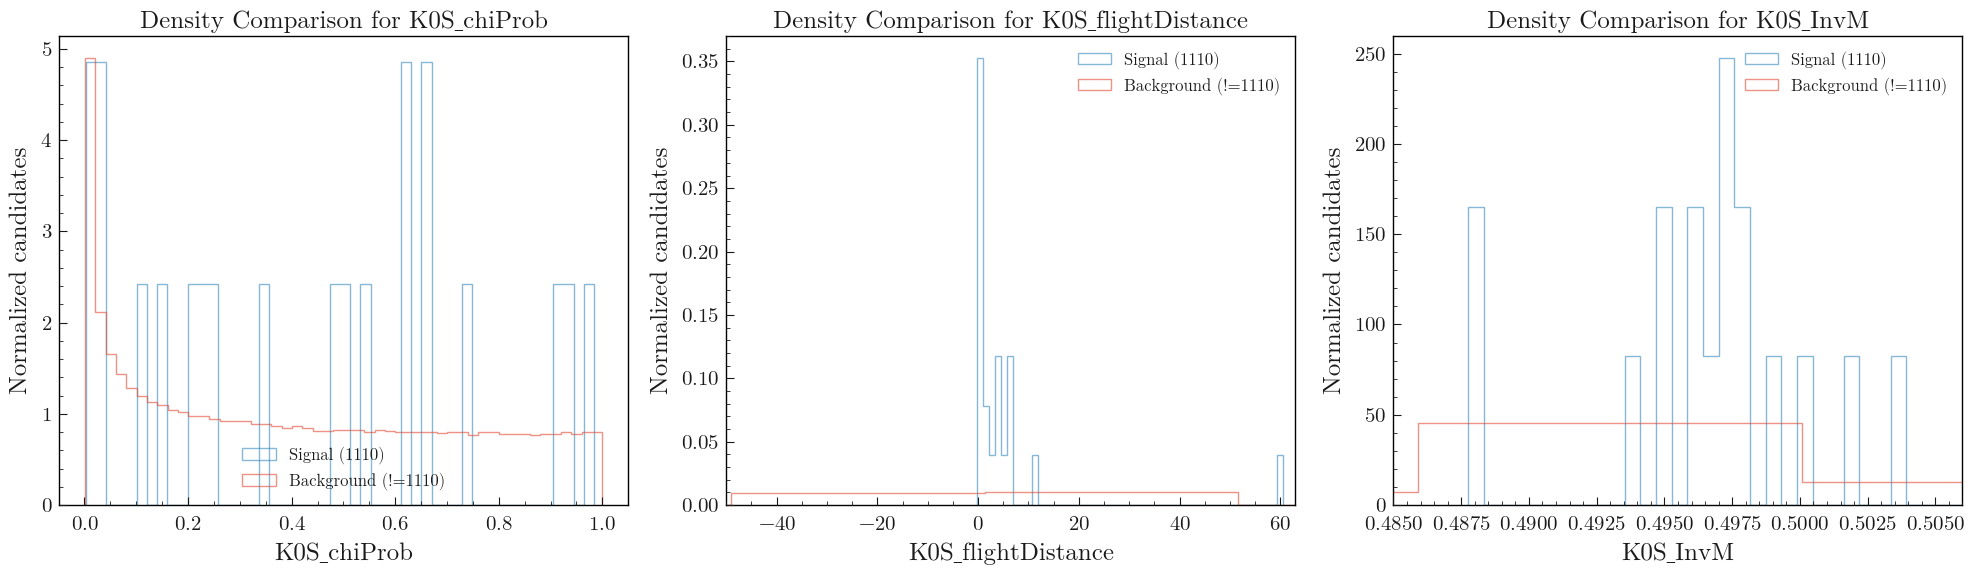

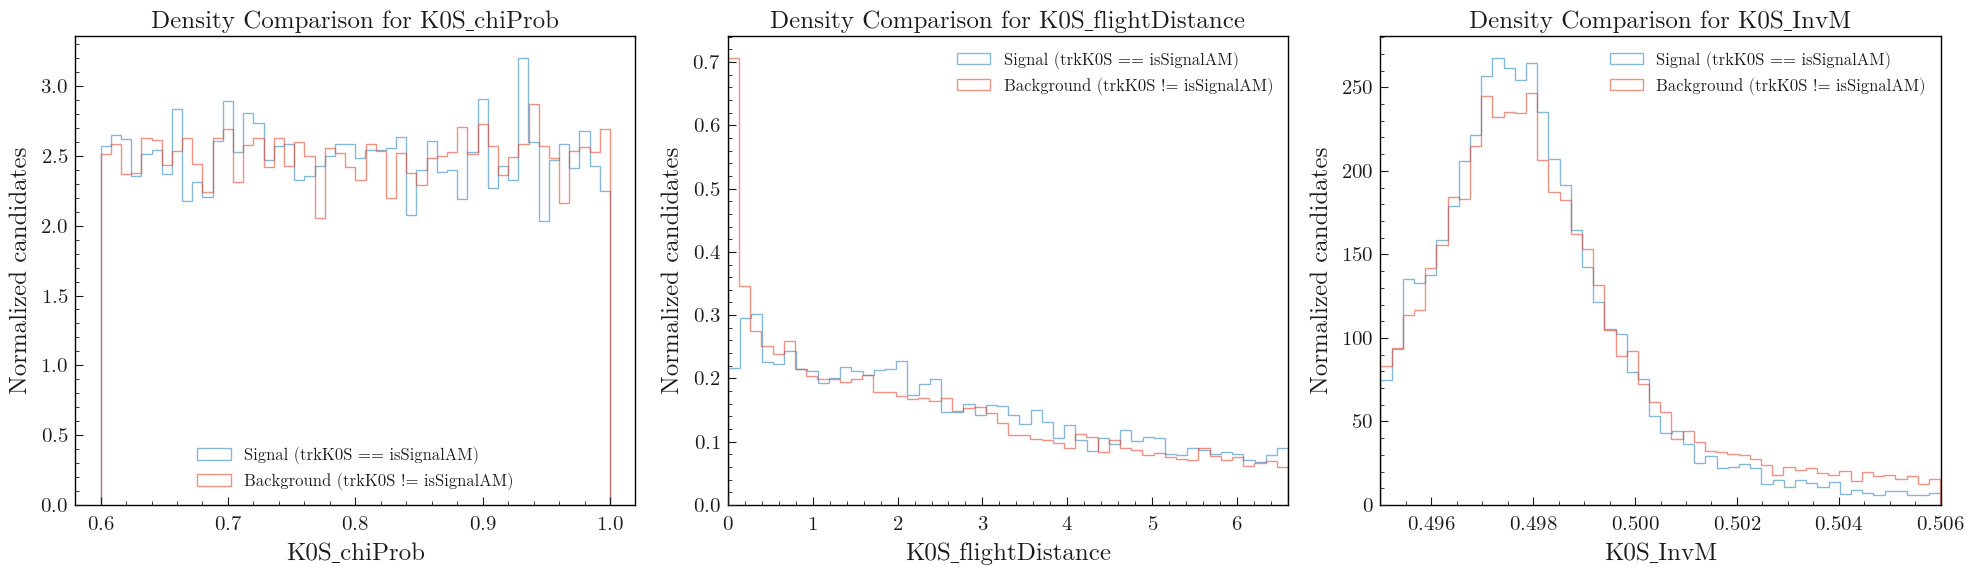

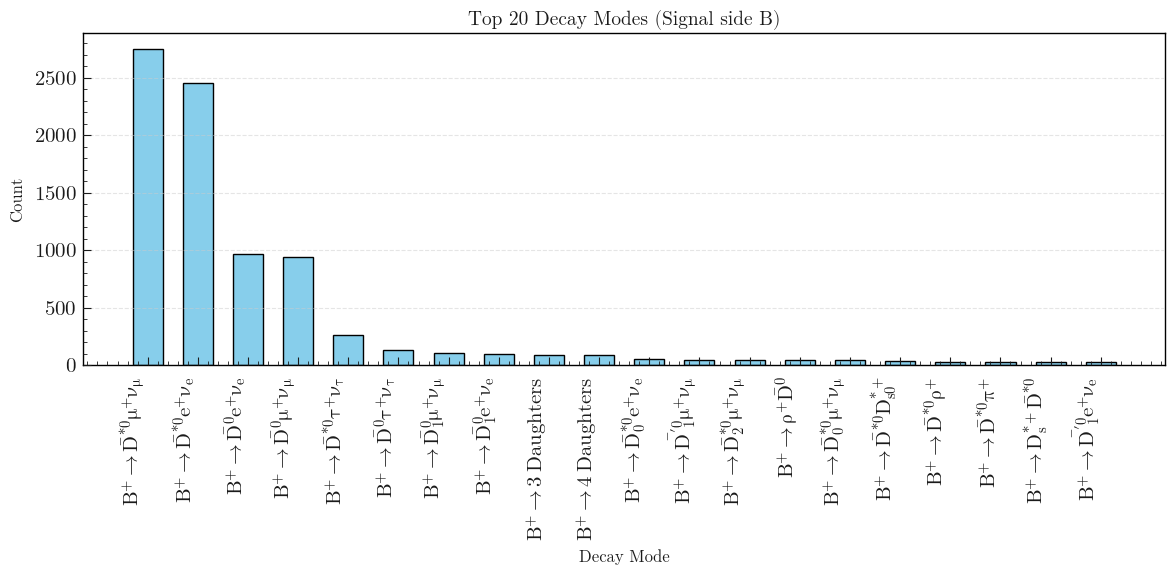

In [18]:



sig_ini = df_asim.query('signal == 1110')
bkg_ini = df_asim.query('signal != 1110')

fig0, ax0 = plt.subplots(1, 3, figsize=(20, 6))
ax0 = ax0.flatten()

vars_to_plot = ['K0S_chiProb', 'K0S_flightDistance', 'K0S_InvM']

for i, var in enumerate(vars_to_plot):
    ax0[i].hist(sig_ini[var], bins=50, density=True, alpha=0.6, label='Signal (1110)',histtype='step')
    ax0[i].hist(bkg_ini[var], bins=50, density=True, alpha=0.6, label='Background (!=1110)',histtype='step')
    ax0[i].set_xlabel(var)
    ax0[i].set_ylabel(f'Normalized candidates')
    ax0[i].legend()
    ax0[i].set_title(f"Density Comparison for {var}")
    ax0[2].set_xlim(0.485,0.506)
    ax0[1].set_xlim(-50,63)
plt.tight_layout()
plt.show()
fig0.savefig("show1.svg", format='svg', bbox_inches='tight')
# #mimic by doing <0.6 chi prob, 0 to 6.6 FD. 4.95 to 4.98
def sel_mimic(df):
    df_t = df.copy()
    df_t = df_t.query('(K0S_InvM > 0.495) & (K0S_InvM < 0.506) & (K0S_flightDistance > 0) & (K0S_flightDistance < 6.6) & (K0S_chiProb > 0.6) & (nROE_Ch == 0)')
    return df_t
sel_mim = sel_mimic(df_asim)
fig1, ax1 = plt.subplots(1, 3, figsize=(20, 6))

sig_ini2 = sel_mim.query('trkK0S_isSignalAcceptMissing == 1')
bkg_ini2 = sel_mim.query('trkK0S_isSignalAcceptMissing != 1')
for i, var in enumerate(vars_to_plot):
    ax1[i].hist(sig_ini2[var], bins=50, density=True, alpha=0.6, label='Signal (trkK0S == isSignalAM)',histtype='step')
    ax1[i].hist(bkg_ini2[var], bins=50, density=True, alpha=0.6, label='Background (trkK0S != isSignalAM)',histtype='step')
    ax1[i].set_xlabel(var)
    ax1[i].set_ylabel(f'Normalized candidates')
    ax1[i].legend()
    ax1[i].set_title(f"Density Comparison for {var}")
    ax1[2].set_xlim(0.495,0.506)
    ax1[1].set_xlim(0,6.6)
plt.tight_layout()
plt.show()
top_twent = sig_ini2['signal'].value_counts().head(20)
cols = top_twent.index
fig1.savefig("show2.svg", format='svg', bbox_inches='tight')



top_twent = sig_ini2['signal'].value_counts().head(20)
cols = top_twent.index
vals = top_twent.values
col2 = [f"${all_modes['Bplus'][col]}$" for col in cols]
fig3 = plt.figure(figsize=(12, 6))
plt.bar(range(len(vals)), vals, width=0.6, color='skyblue', edgecolor='black')
plt.xlabel("Decay Mode", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Top 20 Decay Modes (Signal side B)", fontsize=14)
plt.xticks(ticks=range(len(vals)), labels=col2, rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
fig3.savefig("show3.svg", format='svg', bbox_inches='tight')

In [19]:
# sig_ini = df_asim.query('(trkK0S_isSignalAcceptMissing == 1) & (trkK0S_genMotherPDG_0 == 300553.0) & (nROE_Ch == 0) & (M_ROE < 1.67)')
# bkg_ini = df_asim.query('(trkK0S_isSignalAcceptMissing != 1) | (trkK0S_genMotherPDG_0 != 300553.0) | (nROE_Ch != 0) & (M_ROE >= 1.67)')
# # sig_ini = sig_ini.query('M_ROE < 1.67') #check MROE <1.67 solo later, neat result
# # bkg_ini = bkg_ini.query('M_ROE >= 1.67')
# #sig_ini = df_asim.query('(nROE_Ch == 0) & (M_ROE < 1.67) & (Eextra_ROE < 0.021) & (cosTBTO < 0.012) & (Eextra_ROE_loose < 0.261)')
# #bkg_ini = df_asim.query('(nROE_Ch != 0) & (M_ROE >= 1.67) & (Eextra_ROE >= 0.021) & (cosTBTO >= 0.012) & (Eextra_ROE_loose >= 0.261)')
# binsc=80
# ncols=3
# nrows=(len(sig_vars)+ncols-1)//ncols
# fig,axs=plt.subplots(nrows,ncols,figsize=(20*ncols,20*nrows),squeeze=False)
# formatter=ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((4,9))
# formatter.set_useOffset(False)
# for i,var in enumerate(sig_vars):
#     r,c=divmod(i,ncols)
#     s=sig_ini[var].replace([np.inf,-np.inf],np.nan).dropna()
#     b=bkg_ini[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #s2=signal2[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #b2=background2[var].replace([np.inf,-np.inf],np.nan).dropna()
#     combined=pd.concat([s,b])
#     #combined2=pd.concat([s2,b2])
#     if combined.empty or combined.min()==combined.max():axs[r][c].axis('off');continue
#     #if combined2.empty or combined2.min()==combined2.max():axs[r][c].axis('off');continue
#     xmin,xmax=combined.min(),combined.max()
#     #xmin2,xmax2=combined2.min(),combined2.max()
#     pad=(xmax-xmin)*0.01
#     bin_edges=np.linspace(xmin,xmax,binsc+1)
#     bin_width=bin_edges[1]-bin_edges[0]
#     axs[r][c].hist(b,bins=binsc,range=(xmin,xmax),histtype='step',color='red',lw=5,label='Background')
#     axs[r][c].hist(s,bins=binsc,range=(xmin,xmax),histtype='step',color='blue',lw=5,label='signal')
#     #axs[r][c].hist(b2,bins=binsc,range=(xmin2,xmax2),histtype='step',color='orange',lw=5,label='Background 2')
#     #axs[r][c].hist(s2,bins=binsc,range=(xmin2,xmax2),histtype='step',color='cyan',lw=5,label='signal 2')
#     #axs[r][c].axvline(val, color='red', linestyle='--', label=f'Best cut = {val:.3f}')
# #1.67 MROE, 0.24 Eextra
#     axs[r][c].set_xlabel(var)
#     axs[r][c].set_ylabel(f'Candidates / {bin_width:.2g}')
#     axs[r][c].set_facecolor('black')
#     axs[r][c].set_xlim(xmin-pad,xmax+pad)
#     axs[r][c].set_xticks(np.linspace(xmin,xmax,16))
#     maxy=axs[r][c].get_ylim()[1]
#     axs[r][c].set_ylim(0,maxy*1.001)
#     axs[r][c].set_yticks(np.linspace(0,maxy*1.001,16))
#     axs[r][c].yaxis.set_major_formatter(formatter)
#     axs[r][c].ticklabel_format(axis='y',style='sci',scilimits=(4,9))
#     axs[r][c].grid(True,color='gray',alpha=0.6,linestyle='--',linewidth=1)
#     axs[r][c].legend(frameon=False)
#     for text in axs[r][c].get_legend().get_texts(): text.set_color('white')
# for j in range(i+1,nrows*ncols):r,c=divmod(j,ncols);axs[r][c].axis('off')
# fig.suptitle('Signal Vs Background Plots',fontsize=28)
# fig.savefig("sig_chgtrk.pdf")
# plt.tight_layout(rect=[0,0,1,0.97])
# plt.show()


In [20]:
# ini_cuts = {'low': [], 'high': [], 'center': [],'fom': []}
# for var in ['nROE_Ch', 'nROE_ECL', 'nROE_KL', 'M_ROE', 'Eextra_ROE', 'R2', #'cosTBTO',
#      'nROE_ECL_loose', 'M_ROE_loose', 'Eextra_ROE_loose','K0S_InvM', 'K0S_dr', 'K0S_dz']: #'K0S_cosThCM', 'K0S_phiCM', 'K0S_charge', 'K0S_chiProb', 'K0S_flightDistance', ,
#      #'nISR', 'cosK0Strk']:
#     sig_vals = np.array(sig_ini[var])
#     bkg_vals = np.array(bkg_ini[var])
#     lo, hi, cent, fom = get_foms(sig_vals, bkg_vals, 100)
#     ini_cuts['low'].append(lo)
#     ini_cuts['high'].append(hi)
#     ini_cuts['center'].append(cent)
#     ini_cuts['fom'].append(fom) NOPE
sig_vals = np.array(sig_ini['Eextra_ROE'])
bkg_vals = np.array(bkg_ini['Eextra_ROE']) #Note, FOM says to keep charged tracks in ROE but whatever
#vals = get_foms(sig_vals, bkg_vals, 700) #Although highest ratio of signal to background says no charged tracks


In [21]:
# sig_ini['nROE_Ch'].value_counts(), bkg_ini['nROE_Ch'].value_counts()
# sig_ini2 = sig_ini.query('nROE_Ch == 0')
# bkg_ini2 = sig_ini.query('nROE_Ch != 0') #try 0.254


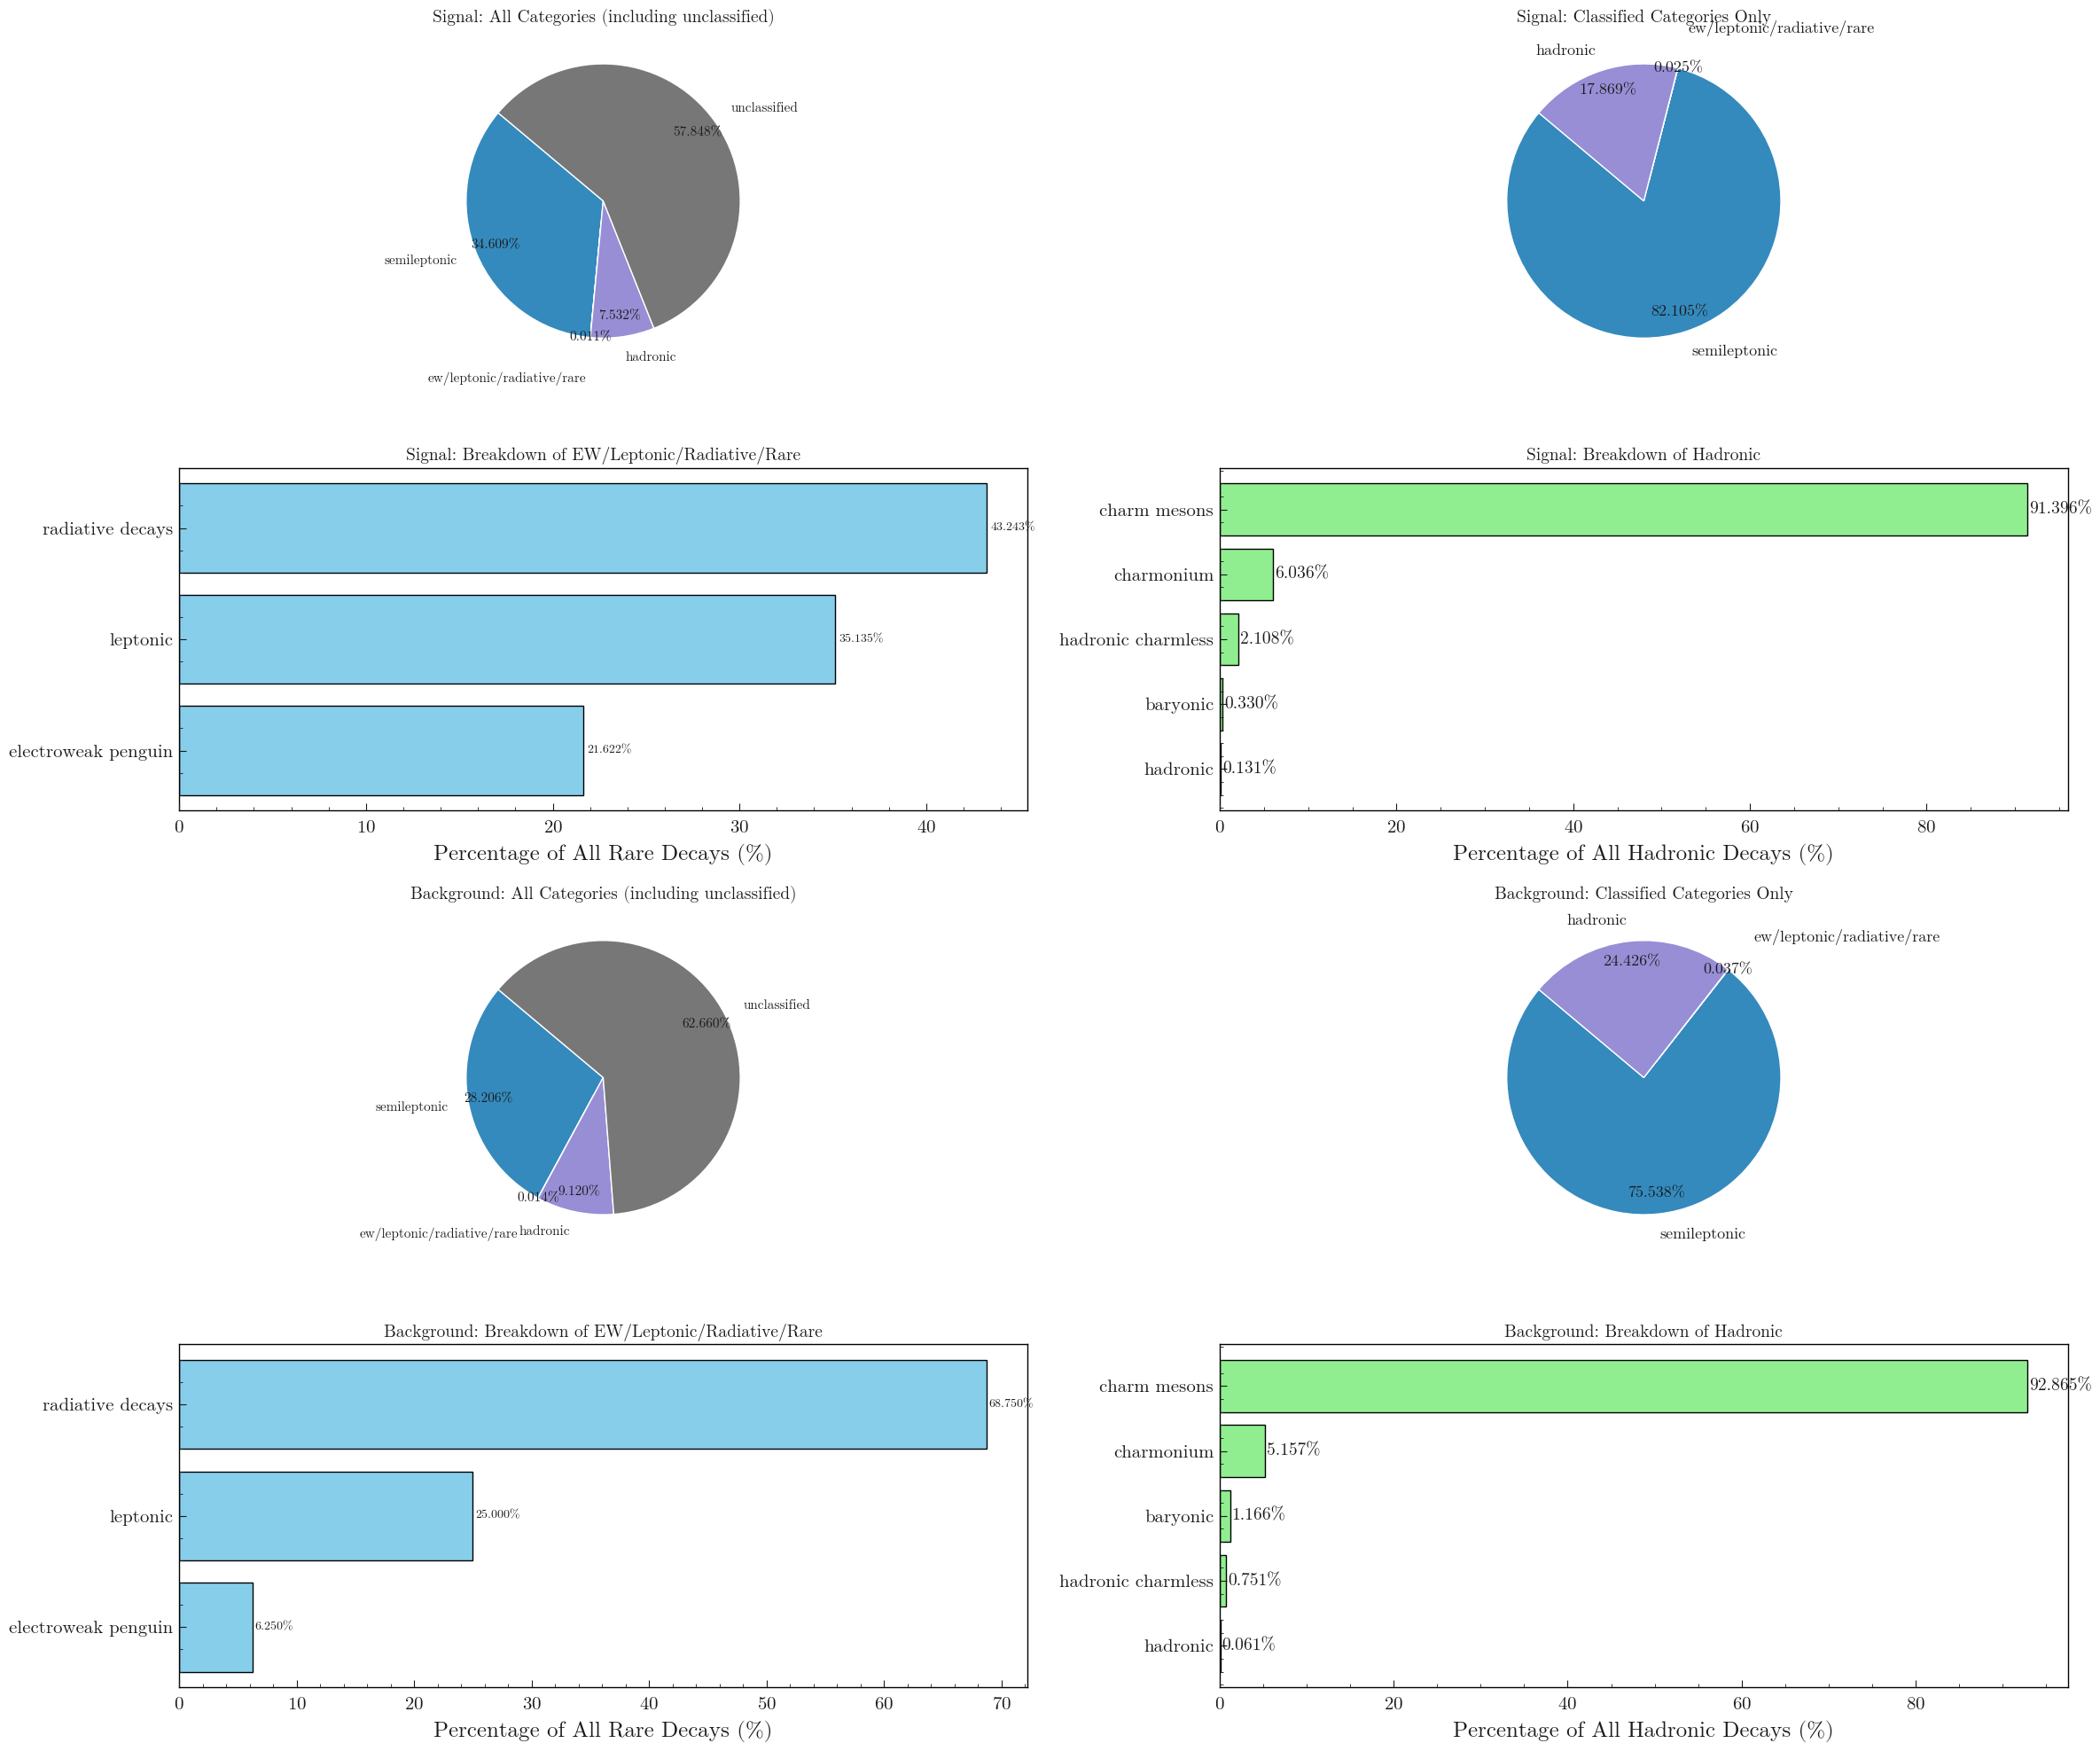

In [22]:


def plot_full_ovc_summary(sig_ovc, sig_ovc2, sig_decomp_rare, sig_decomp_hadron,
                          bkg_ovc, bkg_ovc2, bkg_decomp_rare, bkg_decomp_hadron):

    fig = plt.figure(figsize=(24, 20))
    grid = fig.add_gridspec(4, 2)

    datasets = [
        ("Signal", sig_ovc, sig_ovc2, sig_decomp_rare, sig_decomp_hadron),
        ("Background", bkg_ovc, bkg_ovc2, bkg_decomp_rare, bkg_decomp_hadron)
    ]

    for i, (prefix, ovc, ovc2, rare, hadron) in enumerate(datasets):
        labels_all = list(ovc.keys())
        sizes_all = list(ovc.values())
        explode_all = [0.15 if s < 5 else 0 for s in sizes_all]

        ax1 = fig.add_subplot(grid[i*2, 0])
        ax1.pie(
            sizes_all,
            labels=labels_all,
            explode=explode_all,
            autopct=lambda pct: f"{pct:.3f}%" if pct > 0 else "",
            startangle=140,
            pctdistance=0.85,
            labeldistance=1.15,
            textprops={'fontsize': 11},
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        ax1.set_title(f"{prefix}: All Categories (including unclassified)", fontsize=14)

        classified_keys = [k for k in ovc if k != 'unclassified']
        sizes_classified = [ovc2[k] for k in classified_keys]
        explode_classified = [0.15 if s < 5 else 0 for s in sizes_classified]

        ax2 = fig.add_subplot(grid[i*2, 1])
        ax2.pie(
            sizes_classified,
            labels=classified_keys,
            explode=explode_classified,
            autopct=lambda pct: f"{pct:.3f}%" if pct > 0 else "",
            startangle=140,
            pctdistance=0.85,
            labeldistance=1.15,
            textprops={'fontsize': 13},
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        ax2.set_title(f"{prefix}: Classified Categories Only", fontsize=14)

        rare_items = sorted(rare.items(), key=lambda x: x[1])
        rare_labels, rare_vals = zip(*rare_items)

        ax3 = fig.add_subplot(grid[i*2+1, 0])
        ax3.barh(rare_labels, rare_vals, color='skyblue', edgecolor='black')
        ax3.set_title(f"{prefix}: Breakdown of EW/Leptonic/Radiative/Rare", fontsize=14)
        ax3.set_xlabel("Percentage of All Rare Decays (%)")
        for j, v in enumerate(rare_vals):
            ax3.text(v + 0.2, j, f"{v:.3f}%", va='center', fontsize=10)

        hadron_items = sorted(hadron.items(), key=lambda x: x[1])
        hadron_labels, hadron_vals = zip(*hadron_items)

        ax4 = fig.add_subplot(grid[i*2+1, 1])
        ax4.barh(hadron_labels, hadron_vals, color='lightgreen', edgecolor='black')
        ax4.set_title(f"{prefix}: Breakdown of Hadronic", fontsize=14)
        ax4.set_xlabel("Percentage of All Hadronic Decays (%)")
        for j, v in enumerate(hadron_vals):
            ax4.text(v + 0.2, j, f"{v:.3f}%", va='center', fontsize=14)

    plt.tight_layout()
    plt.show()


    #fig.savefig("pie_.pdf")
plot_full_ovc_summary(
    sig_ovc=b,
    sig_ovc2=c,
    sig_decomp_rare=d,
    sig_decomp_hadron=e,
    bkg_ovc=g,
    bkg_ovc2=h,
    bkg_decomp_rare=ii,
    bkg_decomp_hadron=j
)
ncols=3
nrows=(len(sig_vars)+ncols-1)//ncols
fig,axs=plt.subplots(nrows,ncols,figsize=(20*ncols,20*nrows),squeeze=False)
sig_ini = df_asim.query('signal == 1110')
axs = axs.flatten()
for i, var in zip(range(len(sig_vars)),sig_vars):
    h = ph.make_hist(sig_ini[var],bins=50)
    ph.plot_hist(h,ax=axs[i])
    axs[i].set_xlabel(var)
    axs[i].set_ylabel(f"Candidates / GeV")



In [2]:
# # sig_ini = df_asim.query('(trkK0S_isSignalAcceptMissing == 1)')
# # bkg_ini = df_asim.query('(trkK0S_isSignalAcceptMissing != 1)') #experimented with & for both, for & and gamma 4s for both
# # sig_ini = sig_ini.query('(nROE_Ch == 0)')
# # bkg_ini = bkg_ini.query('(nROE_Ch == 0)')
# # sig_ini = sig_ini.query('(M_ROE < 0.184)')
# # bkg_ini = bkg_ini.query('(M_ROE < 0.184)')
# # sig_ini = sig_ini.query('(Eextra_ROE < 0.05)')
# # bkg_ini = bkg_ini.query('(Eextra_ROE < 0.05)')
# # sig_ini = sig_ini.query('(K0S_InvM > 0.489) & (K0S_InvM < 0.5056)')
# # bkg_ini = bkg_ini.query('(K0S_InvM > 0.489) & (K0S_InvM < 0.5056)')
# # len(sig_ini),len(bkg_ini)
# sig_ini = df_asim.query('signal == 1110')
# binsc=80
# ncols=3
# nrows=(len(sig_vars)+ncols-1)//ncols
# fig,axs=plt.subplots(nrows,ncols,figsize=(20*ncols,20*nrows),squeeze=False)
# formatter=ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((4,9))
# formatter.set_useOffset(False)
# for i,var in enumerate(sig_vars):
#     r,c=divmod(i,ncols)
#     s=sig_ini[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #b=bkg_ini[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #s2=signal2[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #b2=background2[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #combined=pd.concat([s,b])
#     #combined2=pd.concat([s2,b2])
#     #if combined.empty or combined.min()==combined.max():axs[r][c].axis('off');continue
#     #if combined2.empty or combined2.min()==combined2.max():axs[r][c].axis('off');continue
#     xmin,xmax=s.min(), s.max()
#     #xmin2,xmax2=combined2.min(),combined2.max()
#     pad=(xmax-xmin)*0.01
#     bin_edges=np.linspace(xmin,xmax,binsc+1)
#     bin_width=bin_edges[1]-bin_edges[0]
#     #axs[r][c].hist(b,bins=binsc,range=(xmin,xmax),histtype='step',color='red',lw=5,label='Background')
#     axs[r][c].hist(s,bins=binsc,range=(xmin,xmax),histtype='step',color='blue',lw=5,label='signal')
#     #axs[r][c].hist(b2,bins=binsc,range=(xmin2,xmax2),histtype='step',color='orange',lw=5,label='Background 2')
#     #axs[r][c].hist(s2,bins=binsc,range=(xmin2,xmax2),histtype='step',color='cyan',lw=5,label='signal 2')
#     #axs[r][c].axvline(val, color='red', linestyle='--', label=f'Best cut = {val:.3f}')
# #1.67 MROE, 0.24 Eextra
#     axs[r][c].set_xlabel(var)
#     axs[r][c].set_ylabel(f'Candidates / {bin_width:.2g}')
#     axs[r][c].set_facecolor('black')
#     axs[r][c].set_xlim(xmin-pad,xmax+pad)
#     axs[r][c].set_xticks(np.linspace(xmin,xmax,16))
#     maxy=axs[r][c].get_ylim()[1]
#     axs[r][c].set_ylim(0,maxy*1.001)
#     axs[r][c].set_yticks(np.linspace(0,maxy*1.001,16))
#     axs[r][c].yaxis.set_major_formatter(formatter)
#     axs[r][c].ticklabel_format(axis='y',style='sci',scilimits=(4,9))
#     axs[r][c].grid(True,color='gray',alpha=0.6,linestyle='--',linewidth=1)
#     axs[r][c].legend(frameon=False)
#     for text in axs[r][c].get_legend().get_texts(): text.set_color('white')
# for j in range(i+1,nrows*ncols):r,c=divmod(j,ncols);axs[r][c].axis('off')
# fig.suptitle('Signal Vs Background Plots',fontsize=28)
# fig.savefig("sig_chgtrk.pdf")
# plt.tight_layout(rect=[0,0,1,0.97])
# plt.show()

# """Graph, commented out for smooth"""

In [1]:

# # sig_ini = sig_ini.query('M_ROE < 1.67') #check MROE <1.67 solo later, neat result
# # bkg_ini = bkg_ini.query('M_ROE >= 1.67')
# #sig_ini = df_asim.query('(nROE_Ch == 0) & (M_ROE < 1.67) & (Eextra_ROE < 0.021) & (cosTBTO < 0.012) & (Eextra_ROE_loose < 0.261)')
# #bkg_ini = df_asim.query('(nROE_Ch != 0) & (M_ROE >= 1.67) & (Eextra_ROE >= 0.021) & (cosTBTO >= 0.012) & (Eextra_ROE_loose >= 0.261)')
# binsc=80
# ncols=3
# nrows=(len(sig_vars)+ncols-1)//ncols
# fig,axs=plt.subplots(nrows,ncols,figsize=(20*ncols,20*nrows),squeeze=False)
# formatter=ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((4,9))
# formatter.set_useOffset(False)
# for i,var in enumerate(sig_vars):
#     r,c=divmod(i,ncols)
#     s=sig_ini[var].replace([np.inf,-np.inf],np.nan).dropna()
#     b=bkg_ini[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #s2=signal2[var].replace([np.inf,-np.inf],np.nan).dropna()
#     #b2=background2[var].replace([np.inf,-np.inf],np.nan).dropna()
#     combined=pd.concat([s,b])
#     #combined2=pd.concat([s2,b2])
#     if combined.empty or combined.min()==combined.max():axs[r][c].axis('off');continue
#     #if combined2.empty or combined2.min()==combined2.max():axs[r][c].axis('off');continue
#     xmin,xmax=combined.min(),combined.max()
#     #xmin2,xmax2=combined2.min(),combined2.max()
#     pad=(xmax-xmin)*0.01
#     bin_edges=np.linspace(xmin,xmax,binsc+1)
#     bin_width=bin_edges[1]-bin_edges[0]
#     axs[r][c].hist(b,bins=binsc,range=(xmin,xmax),histtype='step',color='red',lw=5,label='Background')
#     axs[r][c].hist(s,bins=binsc,range=(xmin,xmax),histtype='step',color='blue',lw=5,label='signal')
#     #axs[r][c].hist(b2,bins=binsc,range=(xmin2,xmax2),histtype='step',color='orange',lw=5,label='Background 2')
#     #axs[r][c].hist(s2,bins=binsc,range=(xmin2,xmax2),histtype='step',color='cyan',lw=5,label='signal 2')
#     #axs[r][c].axvline(val, color='red', linestyle='--', label=f'Best cut = {val:.3f}')
# #1.67 MROE, 0.24 Eextra
#     axs[r][c].set_xlabel(var)
#     axs[r][c].set_ylabel(f'Candidates / {bin_width:.2g}')
#     axs[r][c].set_facecolor('black')
#     axs[r][c].set_xlim(xmin-pad,xmax+pad)
#     axs[r][c].set_xticks(np.linspace(xmin,xmax,16))
#     maxy=axs[r][c].get_ylim()[1]
#     axs[r][c].set_ylim(0,maxy*1.001)
#     axs[r][c].set_yticks(np.linspace(0,maxy*1.001,16))
#     axs[r][c].yaxis.set_major_formatter(formatter)
#     axs[r][c].ticklabel_format(axis='y',style='sci',scilimits=(4,9))
#     axs[r][c].grid(True,color='gray',alpha=0.6,linestyle='--',linewidth=1)
#     axs[r][c].legend(frameon=False)
#     for text in axs[r][c].get_legend().get_texts(): text.set_color('white')
# for j in range(i+1,nrows*ncols):r,c=divmod(j,ncols);axs[r][c].axis('off')
# fig.suptitle('Signal Vs Background Plots',fontsize=28)
# fig.savefig("sig_chgtrk.pdf")
# plt.tight_layout(rect=[0,0,1,0.97])
# plt.show()
"""Graph, commented out for smooth"""

'Graph, commented out for smooth'

In [ ]:
df

In [ ]:
# h = plt.hist(np.random.normal(size=1000),bins=30, range=(-3,3), histtype="step", lw=2, color='black')

# plt.xlabel(r"$Q$ Mass $/\sqrt{\gamma\epsilon}$  [GeV/$\mathrm{c}^2$]")
# plt.ylabel(r"Entries / (0.2 GeV/$\mathrm{c}^2$)")
# plt.title("Example Belle II Style with matplotlib")


In [ ]:
bincnt = 100
sig_1 = sig_1.query('nROE_Ch < 1')
bkg_1 = bkg_1.query('nROE_Ch < 1')
sig_vals = sig_1['Eextra_ROE']
bkg_vals = bkg_1['Eextra_ROE']
sig_h1 = ph.make_hist(sig_vals, bins=bincnt)
bkg_h1 = ph.make_hist(bkg_vals,bins=bincnt)
fig_h1, ax_h1 = plt.subplots(2,2,figsize=(20,20))
ax_h1 = ax_h1.flatten()
ph.plot_hist(sig_h1,ax=ax_h1[0],label='Signal K0S + TRK')
ph.plot_hist(bkg_h1,ax=ax_h1[0],label='Background')
ax_h1[0].legend()

thresh = np.arange(min(sig_vals), max(bkg_vals)+0.0001,0.0001)
best_fom = -100
best_t = -100
for t in thresh:
    S = np.sum(sig_vals <= t)
    B = np.sum(bkg_vals <= t)
    if S+B != 0:
        fom = S/np.sqrt(S+B)
    else:
        fom = -100
    if fom > best_fom:
        best_fom = fom
        best_t = t

def fom_scan_cut_low(sig_series, bkg_series, nbins=300):
    import numpy as np

    # Clean data
    sig_vals = sig_series.replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    bkg_vals = bkg_series.replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    # Define histogram bins
    minval = min(sig_vals.min(), bkg_vals.min())
    maxval = max(sig_vals.max(), bkg_vals.max())
    bins = np.linspace(minval, maxval, nbins + 1)

    # Histogram and cumulative sums for < cuts
    S_hist, _ = np.histogram(sig_vals, bins=bins)
    B_hist, _ = np.histogram(bkg_vals, bins=bins)

    S_cumsum = np.cumsum(S_hist)
    B_cumsum = np.cumsum(B_hist)

    fom = np.divide(S_cumsum, np.sqrt(S_cumsum + B_cumsum), out=np.zeros_like(S_cumsum, dtype=float), where=(S_cumsum + B_cumsum) != 0)
    centers = 0.5 * (bins[:-1] + bins[1:])

    best_idx = np.argmax(fom)
    best_thresh = centers[best_idx]
    best_fom = fom[best_idx]

    return best_thresh, best_fom, centers, fom

best_thresh, best_fom, centers, fom = fom_scan_cut_low(sig_1['Eextra_ROE'], bkg_1['Eextra_ROE'])

print(f"Best threshold: Eextra_ROE < {best_thresh:.6f}, FoM: {best_fom:.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(centers, fom, label='FoM (S / sqrt(S+B))')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best cut = {best_thresh:.3f}')
plt.xlabel('Eextra_ROE cut (< threshold)')
plt.ylabel('Figure of Merit')
plt.title('FoM vs Eextra_ROE Cut')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
get_foms(np.array(sig_1['Eextra_ROE']),np.array(bkg_1['Eextra_ROE']), 500)

In [ ]:
def best_fom_cut_eextra(sig_series, bkg_series, nbins=1000):

    sig = sig_series.replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    bkg = bkg_series.replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    minval = min(sig.min(), bkg.min())
    maxval = max(sig.max(), bkg.max())
    thresholds = np.linspace(minval, maxval+0.1, nbins)

    best_fom = 0.0
    best_thresh = thresholds[0]

    for t in thresholds:
        S = np.sum(sig < t)
        B = np.sum(bkg < t)
        if S + B > 0:
            fom = S / np.sqrt(S + B)
            if fom > best_fom:
                best_fom = fom
                best_thresh = t

    return best_thresh, best_fom


In [ ]:

best_thresh, best_fom = best_fom_cut_eextra(sig_1['Eextra_ROE'], bkg_1['Eextra_ROE'])
print(f"Best Eextra_ROE cut: < {best_thresh:.6f}, FoM: {best_fom:.3f}")
